# Methanol synthesis loop: PFR surrogate pipeline

One run, top to bottom, from a fresh kernel:

- **A** explore the HYSYS loop over the T-P design box (heatmaps);
- **B** record the reactor inlet the loop produces and turn it into the surrogate's training box;
- **C** sample the isolated PFR over that box and train two surrogates, `stoi` (reaction extents, mass balance by construction) and `raw` (outlet flows directly);
- **D** validate the loop with the PFR replaced by each surrogate against the HYSYS loop, point by point;
- **E** nested-sampling feasibility analysis on the surrogate loop, benchmarked against the same analysis on HYSYS.

HYSYS plumbing lives in `hysys.py`, `hysys_methanol.py`, `hysys_pfr.py`, `hysys_surrogate.py`; sampling and the MLP in `helpers.py`.

In [1]:
# Imports
import time
import itertools
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nested_sampler as ns          # https://github.com/Kai360-dot/NestedSampler

from hysys import open_case
from helpers import generate_sobol_points, fit_mlp, cross_validate, select_width
import hysys_methanol as loop        # full loop, PFR solved by HYSYS       (methanol.hsc)
import hysys_pfr as pfr              # isolated reactor                     (PFR.hsc)
import hysys_surrogate as sur        # loop with the PFR replaced by a net  (open_methanol.hsc)

In [2]:
# KNOBS
SMOKE_TEST = True                  # few points to check the machinery; False for the real run
TAG = "_smoke" if SMOKE_TEST else ""       # suffix of every file this notebook writes

CASES = Path("C:/Users/kr326/Documents/Andrea_Files_MeOH_Aspen/TestAspenFile")
CASE_LOOP = str(CASES / "methanol.hsc")            # original flowsheet
CASE_PFR = str(CASES / "PFR.hsc")                  # reactor with its inlet and outlet streams only
CASE_SUR = str(CASES / "open_methanol.hsc")        # copy of the loop with Reactor100 ignored

# design variables; key order defines x = (T, P) everywhere below
design_bounds = {"temperature_C": [220, 280], "pressure_bar": [70, 120]}
RATIO, PURGE_RATE, VOLUME = 3.0, 0.03, 35          # fixed: H2:CO2 feed ratio, purge fraction, reactor m3
INFLATE = 0.15                                     # widening of the reactor-inlet hull, both sides
NET = "raw"                                        # surrogate in the feasibility analysis: "raw" or "stoi"

# constraints, feasible iff residual <= 0 (see constraints below)
MEOH_MIN = 18_000                  # kg/h methanol product
COMPRESSION_MAX = 4_000            # kW, syngas + recycle compressors
CO_MAX = 6                         # kgmole/h net CO formed in the reactor

# stage sizes
N_GRID = 3 if SMOKE_TEST else 30                       # A: points per axis of the T-P grid
N_DOMAIN = 8 if SMOKE_TEST else 32                     # B: Sobol points of the loop for the inlet hull
N_PFR = 64 if SMOKE_TEST else 1024                     # C: Sobol points of the reactor (power of two)
N_LIVE, N_PROP = (8, 2) if SMOKE_TEST else (200, 20)   # E: nested sampler
MAX_TIME = 300 if SMOKE_TEST else 7200                 # E: s wall time per sampler run

In [3]:
# Setup: attach to the three cases (HYSYS is launched for any that is not open)
t0 = time.time()
case_loop, case_pfr, case_sur = (open_case(c) for c in (CASE_LOOP, CASE_PFR, CASE_SUR))
objects_loop = loop.cache_objects(case_loop)
objects_pfr = pfr.cache_objects(case_pfr)          # objects_sur needs the box from Part B
print(f"three cases attached in {time.time() - t0:.0f} s")

Case not open in HYSYS - launching (this can take a minute)...
Case not open in HYSYS - launching (this can take a minute)...
Case not open in HYSYS - launching (this can take a minute)...
three cases attached in 56 s


In [4]:
# Loop adapters: design vector -> result row, the constraints on a row, and a sweep helper
def row_hysys(x):
    T, P = x
    return loop.run_point(objects_loop, pressure=(P, "bar"), temperature=(T, "C"),
                          volume=(VOLUME, "m3"), ratio=RATIO, purge_rate=PURGE_RATE)

def constraints(row):
    """Residuals, feasible iff every value <= 0."""
    if not row["converged"]:
        raise RuntimeError("not converged")          # sampler drops the point, counts a failure
    return [MEOH_MIN - row["methanol_kg_h"],
            row["compression_kW"] - COMPRESSION_MAX,
            row["co_formation_kgmole_h"] - CO_MAX]

def loop_rows(points, model):
    """One row per design point; a point that raises is kept as not converged."""
    rows = []
    for x in points:
        try:
            rows.append({**model(x), **dict(zip(design_bounds, x))})    # set values win: exact grid keys
        except Exception as e:
            rows.append({**dict(zip(design_bounds, x)), "converged": False, "error": str(e)})
    return pd.DataFrame(rows)

## Part A: loop exploration

In [5]:
# T-P grid of the loop at fixed ratio, purge and volume
T_axis = np.linspace(*design_bounds["temperature_C"], N_GRID)
P_axis = np.linspace(*design_bounds["pressure_bar"], N_GRID)
t0 = time.time()
df_sweep = loop_rows(itertools.product(T_axis, P_axis), row_hysys)
print(f"{len(df_sweep)} points, {int(df_sweep.converged.sum())} converged, {time.time() - t0:.0f} s")

9 points, 7 converged, 33 s


In [6]:
def heatmap(df, value, label, *,
            x="pressure_bar", y="temperature_C",
            levels=16, cmap="viridis", ax=None, title=None):
    """Heatmap of value over (x, y); non-converged cells are left blank."""
    if not df["converged"].all():
        print("Warning: Not all points converged")

    _df = df.copy()
    _df["value_plot"] = _df[value].where(_df["converged"])
    grid = _df.pivot(index=y, columns=x, values="value_plot")
    if ax is None:
        _, ax = plt.subplots(1, 1)
    mesh = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap=cmap, shading="nearest")
    cs = ax.contour(grid.columns, grid.index, grid.values, levels=levels, colors="black", linewidths=1)
    ax.clabel(cs, fmt="%g")
    ax.set_xlabel("Pressure [bar]")
    ax.set_ylabel("T [°C]")
    ax.set_title(title)
    ax.figure.colorbar(mesh, ax=ax, label=label)
    return ax

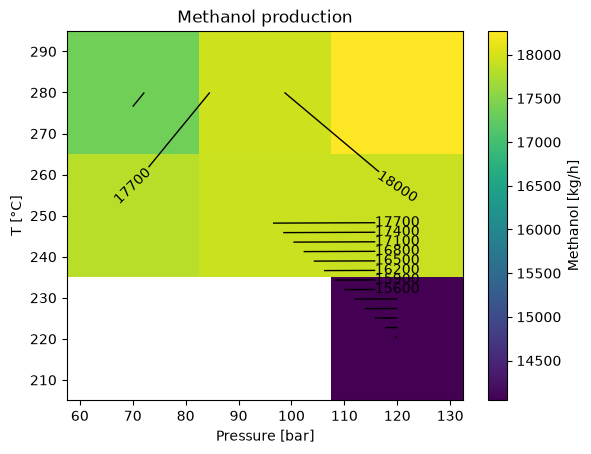

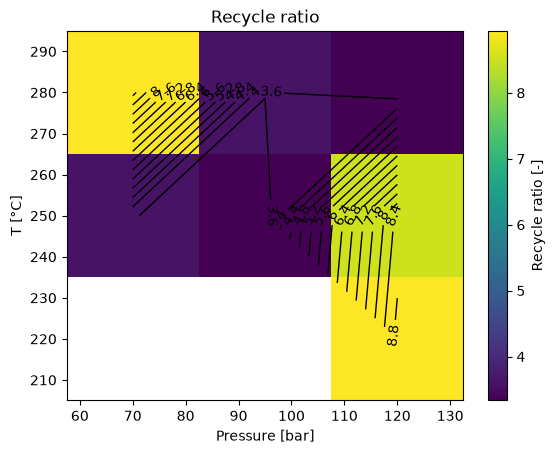

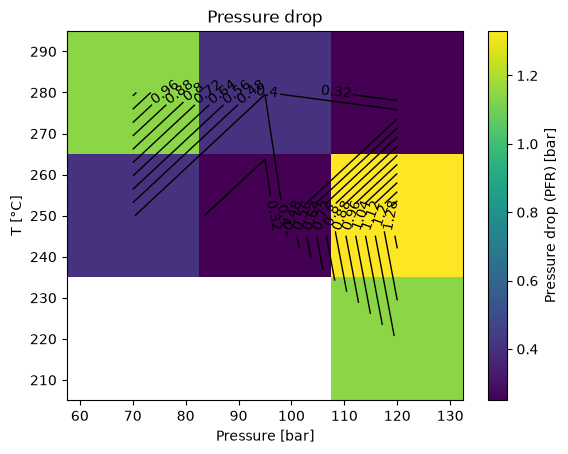

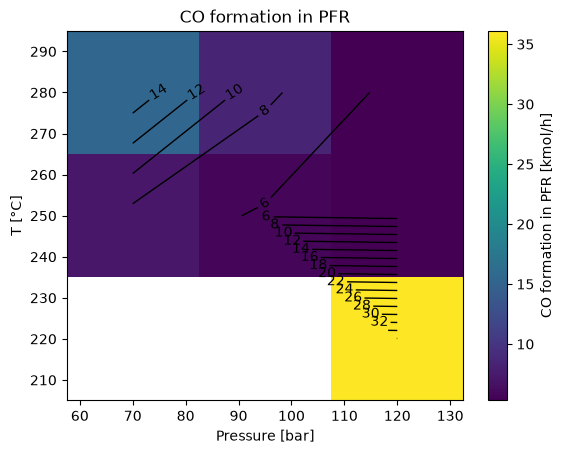

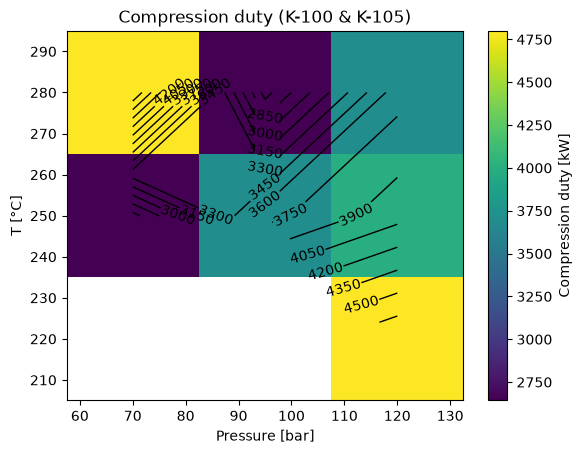

In [7]:
heatmap(df_sweep, "methanol_kg_h", "Methanol [kg/h]", title="Methanol production", levels=15)
heatmap(df_sweep, "recycle_ratio", "Recycle ratio [-]", title="Recycle ratio")
heatmap(df_sweep, "reactor_dP_bar", "Pressure drop (PFR) [bar]", title="Pressure drop")
heatmap(df_sweep, "co_formation_kgmole_h", "CO formation in PFR [kmol/h]", title="CO formation in PFR")
heatmap(df_sweep, "compression_kW", "Compression duty [kW]", title="Compression duty (K-100 & K-105)");

## Part B: reactor-inlet domain, the surrogate's training box

In [8]:
# Sobol sample of the loop over the design box; run_point records the reactor inlet at each point
bounds = np.array(list(zip(*design_bounds.values())))          # 2 x d: lower row, upper row
t0 = time.time()
df_dom = loop_rows(generate_sobol_points(N_DOMAIN, bounds), row_hysys)
print(f"{len(df_dom)} points, {int(df_dom.converged.sum())} converged, {time.time() - t0:.0f} s")

8 points, 8 converged, 55 s


In [9]:
# Hull of the reactor inlet over the converged points, inflated -> training box in sur.INPUTS order
dom_ok = df_dom[df_dom["converged"]].reset_index(drop=True)
hull = {c: (dom_ok[f"in_{c}_kgmole_h"].min() / 3600, dom_ok[f"in_{c}_kgmole_h"].max() / 3600)   # kgmole/s
        for c in sur.COMPONENTS}
pfr_box = {**design_bounds, **{c: [lo * (1 - INFLATE), hi * (1 + INFLATE)] for c, (lo, hi) in hull.items()}}
assert list(pfr_box) == sur.INPUTS
pd.DataFrame(pfr_box, index=["lower", "upper"]).T

,lower,upper
temperature_C,220.000000,280.000000
pressure_bar,70.000000,120.000000
Hydrogen,1.985391,5.318599
CO,0.037134,0.275081
CO2,0.404104,1.328673
H2O,0.006875,0.011592
Methanol,0.003626,0.014362
Nitrogen,0.048514,0.068240


## Part C: PFR sampling and surrogate training

In [10]:
# Reactor sampling: vector in pfr_box order -> one HYSYS solve of the isolated PFR
def pfr_row(x):
    p = dict(zip(pfr_box, x))
    return pfr.run_point(objects_pfr, temperature=(p["temperature_C"], "C"), pressure=(p["pressure_bar"], "bar"),
                         volume=(VOLUME, "m3"), flows=({c: p[c] for c in sur.COMPONENTS}, "kgmole/s"))

def unit_sobol_sample(bounds, model, n_pts):
    lb = np.array([b[0] for b in bounds.values()])
    ub = np.array([b[1] for b in bounds.values()])
    input_var = generate_sobol_points(n=n_pts, bounds=np.stack((lb, ub)))
    results = []
    for iv in input_var:
        res = {**dict(zip(bounds, iv)), **model(iv)}
        results.append(res)
    return pd.DataFrame(results)

t0 = time.time()
df_pfr = unit_sobol_sample(pfr_box, pfr_row, N_PFR)
print(f"{len(df_pfr)} evaluations, {int(df_pfr.converged.sum())} converged, {time.time() - t0:.0f} s")
df_pfr.to_csv(f"pfr_sobol{TAG}.csv", index=False)

64 evaluations, 64 converged, 2 s


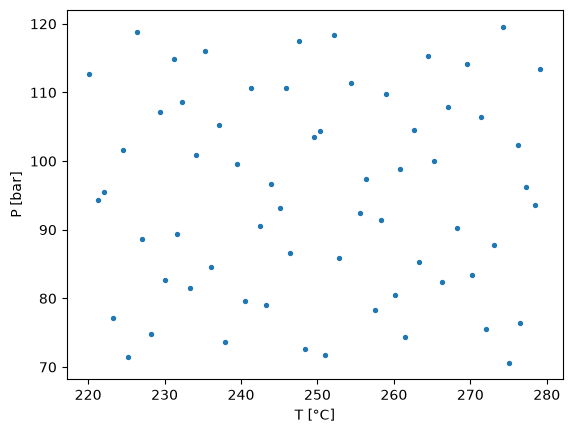

In [11]:
# Sampled design points in the T-P plane; the six flow dimensions are projected out
fig, ax = plt.subplots()
ax.scatter(df_pfr.temperature_C, df_pfr.pressure_bar, s=8)
ax.set(xlabel="T [°C]", ylabel="P [bar]");

In [12]:
# Two surrogates of the same reactor, trained on the same inputs:
#   stoi: predicts the extents of the two independent reactions
#           xi1: CO2 + 3 H2 -> CH3OH + H2O      xi2: CO2 + H2 -> CO + H2O
#         plus duty and pressure drop; outlet = inlet + sur.STOICH @ extents, so the
#         atom balances hold by construction (sur.stoi_as_raw does that reconstruction).
#   raw:  predicts the six outlet flows plus duty and pressure drop directly.
pfr_ok = df_pfr[df_pfr["converged"]].reset_index(drop=True)
X = pfr_ok[list(pfr_box)].to_numpy()                      # inputs in box order
Y_stoi = pd.DataFrame({
    "xi_meoh_kgmole_h": pfr_ok.out_Methanol_kgmole_h - pfr_ok.in_Methanol_kgmole_h,
    "xi_co_kgmole_h":   pfr_ok.out_CO_kgmole_h - pfr_ok.in_CO_kgmole_h,
    "reactor_duty_kW":  pfr_ok.reactor_duty_kW,
    "reactor_dP_bar":   pfr_ok.reactor_dP_bar,
})
Y_raw = pd.concat([pfr_ok[[f"out_{c}_kgmole_h" for c in sur.COMPONENTS]],
                   pfr_ok[["reactor_duty_kW", "reactor_dP_bar"]]], axis=1)
print(f"{len(X)} training points, {X.shape[1]} inputs -> stoi {Y_stoi.shape[1]} outputs, raw {Y_raw.shape[1]} outputs")

64 training points, 8 inputs -> stoi 4 outputs, raw 8 outputs


In [13]:
def train_surrogate(X, Y: pd.DataFrame, name: str):
    """Width search, 5-fold CV report, final fit on all data, export.  Returns (model, rmse, Y_oof)."""
    t0 = time.time()
    width, table = select_width(X, Y.to_numpy(), verbose=False)
    rmse, Y_oof = cross_validate(X, Y.to_numpy(), hidden=width)
    model = fit_mlp(X, Y.to_numpy(), hidden=width)
    model.export(f"pfr_surrogate_{name}{TAG}.txt")
    print(f"=== {name}: width {width} ({time.time() - t0:.0f} s)   CV rmse/std per width: "
          + ", ".join(f"{w}: {v:.4f}" for w, v in table.items()))
    for col, r, span in zip(Y.columns, rmse, Y.max() - Y.min()):
        print(f"  {col:22s} {r:9.3f}   {100 * r / span:5.2f} % of range")
    return model, rmse, Y_oof

stoi, rmse_stoi, oof_stoi = train_surrogate(X, Y_stoi, "stoi")
raw, rmse_raw, oof_raw = train_surrogate(X, Y_raw, "raw")
nets = {"stoi": sur.stoi_as_raw(stoi), "raw": raw}       # both with the raw interface: outlet flows, duty, dP

=== stoi: width 16 (13 s)   CV rmse/std per width: 4: 0.7063, 8: 0.3718, 16: 0.3316, 32: 0.3444
  xi_meoh_kgmole_h         118.960    9.14 % of range
  xi_co_kgmole_h            57.034    6.05 % of range
  reactor_duty_kW         2568.078    8.57 % of range
  reactor_dP_bar             0.069    4.77 % of range
=== raw: width 8 (10 s)   CV rmse/std per width: 4: 0.4504, 8: 0.2740, 16: 0.3813
  out_Hydrogen_kgmole_h    549.423    4.57 % of range
  out_CO_kgmole_h           66.576    9.42 % of range
  out_CO2_kgmole_h         136.888    4.17 % of range
  out_H2O_kgmole_h          66.610    5.65 % of range
  out_Methanol_kgmole_h    110.117    8.36 % of range
  out_Nitrogen_kgmole_h      2.140    3.05 % of range
  reactor_duty_kW         2632.714    8.79 % of range
  reactor_dP_bar             0.072    4.98 % of range


out-of-fold RMSE of outlet flows [kgmole/h]:
             range  stoi_rmse  raw_rmse
Hydrogen  12010.25     317.93    549.42
CO          706.72      57.03     66.58
CO2        3279.03      86.93    136.89
H2O        1178.79      86.93     66.61
Methanol   1316.90     118.96    110.12
Nitrogen     70.06       0.00      2.14

raw net atom balance error, out minus in [kgmole/h]  (stoi: zero by construction):
  C: rms  132.43   max  400.90
  O: rms  255.64   max  797.34
  H: rms 1071.42   max 5080.22


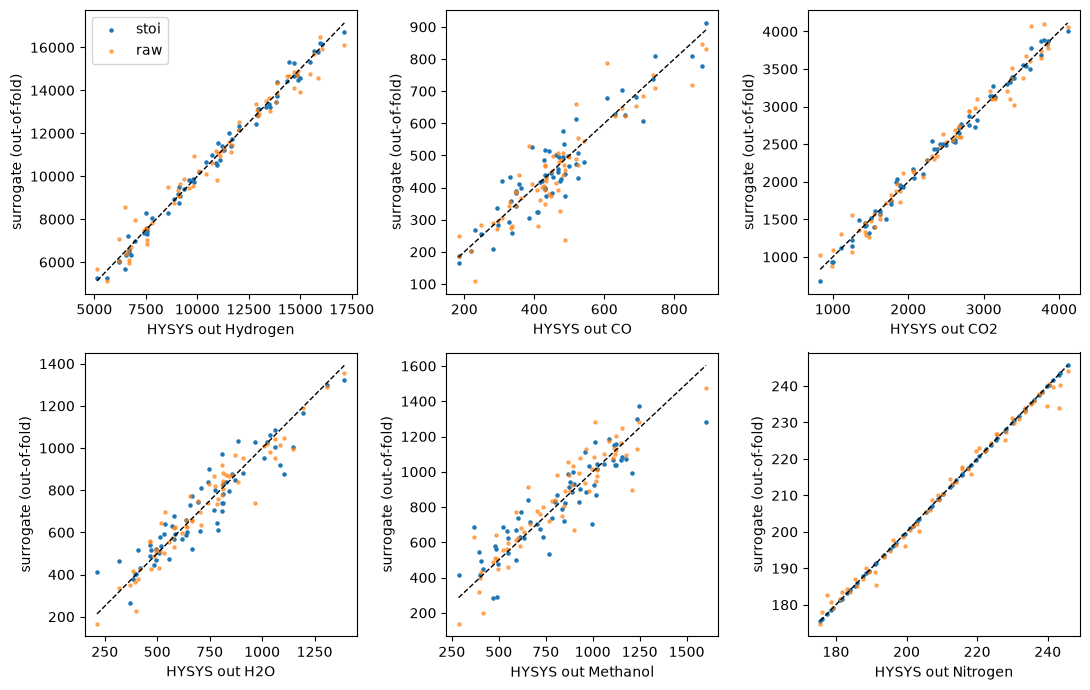

In [14]:
# Side by side on the same footing: outlet flows, with the stoi outlets rebuilt from its
# out-of-fold extents, and the atom balances of the raw net's outlets
inlet = pfr_ok[[f"in_{c}_kgmole_h" for c in sur.COMPONENTS]].to_numpy()
outlet = pfr_ok[[f"out_{c}_kgmole_h" for c in sur.COMPONENTS]].to_numpy()
out_stoi = inlet + oof_stoi[:, :2] @ sur.STOICH.T
comparison = pd.DataFrame({
    "range": outlet.max(0) - outlet.min(0),
    "stoi_rmse": np.sqrt(((out_stoi - outlet) ** 2).mean(0)),
    "raw_rmse": np.sqrt(((oof_raw[:, :6] - outlet) ** 2).mean(0)),
}, index=sur.COMPONENTS).round(2)
print("out-of-fold RMSE of outlet flows [kgmole/h]:")
print(comparison)

ATOMS = {"C": [0, 1, 1, 0, 1, 0], "O": [0, 1, 2, 1, 1, 0], "H": [2, 0, 0, 2, 4, 0]}   # per sur.COMPONENTS
print()
print("raw net atom balance error, out minus in [kgmole/h]  (stoi: zero by construction):")
for atom, v in ATOMS.items():
    err = (oof_raw[:, :6] - inlet) @ np.array(v, float)
    print(f"  {atom}: rms {np.sqrt((err ** 2).mean()):7.2f}   max {np.abs(err).max():7.2f}")

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, c, y, a, b in zip(axes.flat, sur.COMPONENTS, outlet.T, out_stoi.T, oof_raw[:, :6].T):
    ax.scatter(y, a, s=5, label="stoi")
    ax.scatter(y, b, s=5, label="raw", alpha=0.6)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=1)
    ax.set(xlabel=f"HYSYS out {c}", ylabel="surrogate (out-of-fold)")
axes.flat[0].legend()
fig.tight_layout()

In [15]:
# Sanity check on one point: both surrogates against HYSYS
row = pfr_ok.iloc[0]
x = row[list(pfr_box)].to_numpy(dtype=float)
pred = {name: net(x)[:6] for name, net in nets.items()}
for i, c in enumerate(sur.COMPONENTS):
    print(f"  {c:9s} HYSYS {row[f'out_{c}_kgmole_h']:9.2f}   stoi {pred['stoi'][i]:9.2f}   raw {pred['raw'][i]:9.2f} kgmole/h")

  Hydrogen  HYSYS  14685.13   stoi  14687.37   raw  14353.79 kgmole/h
  CO        HYSYS    333.75   stoi    333.88   raw    350.83 kgmole/h
  CO2       HYSYS   1630.65   stoi   1631.30   raw   1459.63 kgmole/h
  H2O       HYSYS    854.83   stoi    854.16   raw    873.29 kgmole/h
  Methanol  HYSYS    701.58   stoi    700.76   raw    720.61 kgmole/h
  Nitrogen  HYSYS    217.54   stoi    217.54   raw    218.14 kgmole/h


## Part D: the loop with the surrogate in place of the PFR

In [16]:
# The cut flowsheet: RoutV is written from the net each tear pass, the rest is solved by HYSYS
objects_sur = sur.cache_objects(case_sur, pfr_box)

def row_surrogate(x, net):
    T, P = x
    return sur.run_point(objects_sur, net, pressure=(P, "bar"), temperature=(T, "C"),
                         ratio=RATIO, purge_rate=PURGE_RATE)

In [17]:
# Point-wise validation against the HYSYS rows of Part B, both nets
KEYS = ["methanol_kg_h", "compression_kW", "co_formation_kgmole_h", "recycle_ratio"]
for name, net in nets.items():
    t0 = time.time()
    pred = loop_rows(dom_ok[list(design_bounds)].to_numpy(), partial(row_surrogate, net=net))
    conv = pred["converged"].to_numpy()
    print(f"=== {name}: {int(conv.sum())}/{len(pred)} converged, mean {pred.tear_passes.mean():.0f} tear passes, "
          f"{int(pred.outside_box.dropna().map(len).gt(0).sum())} points outside the box, {time.time() - t0:.0f} s")
    for k in KEYS:
        err = (pred[k] - dom_ok[k])[conv]
        rmse = np.sqrt((err ** 2).mean())
        print(f"  {k:22s} rmse {rmse:9.3f}   max |err| {err.abs().max():9.3f}   "
              f"({100 * rmse / dom_ok[k].abs().mean():.2f} % of mean)")

=== stoi: 5/8 converged, mean 72 tear passes, 4 points outside the box, 34 s
  methanol_kg_h          rmse  1775.664   max |err|  2980.216   (10.34 % of mean)
  compression_kW         rmse   381.991   max |err|   583.307   (10.52 % of mean)
  co_formation_kgmole_h  rmse     8.689   max |err|    14.543   (72.19 % of mean)
  recycle_ratio          rmse     2.142   max |err|     3.226   (48.25 % of mean)
=== raw: 5/8 converged, mean 78 tear passes, 4 points outside the box, 25 s
  methanol_kg_h          rmse  1038.987   max |err|  1667.483   (6.05 % of mean)
  compression_kW         rmse   380.086   max |err|   562.782   (10.47 % of mean)
  co_formation_kgmole_h  rmse     8.361   max |err|    18.259   (69.47 % of mean)
  recycle_ratio          rmse     2.054   max |err|     4.221   (46.26 % of mean)


## Part E: feasibility analysis, surrogate loop against the HYSYS benchmark

In [18]:
def nested_sample_flowsheet(box, model, constraints, *, n_live, n_prop, max_time=0):
    """Nested-sample the region where constraints(model(x)) <= 0 over `box`
    ({name: [lb, ub]}, order defines x).  Returns the sampler Result and a
    DataFrame with one row per evaluation, failed ones included."""
    rows = []

    def g(x):
        row = {**dict(zip(box, x)), **model(x)}
        rows.append(row)                          # kept even if the constraints raise
        residuals = constraints(row)
        row["max_residual"] = max(residuals)      # <= 0 means feasible
        return residuals

    lb, ub = zip(*box.values())
    result = ns.NestedSampler(g, lb, ub, num_live=n_live, num_prop=n_prop, max_time=max_time).sample()
    return result, pd.DataFrame(rows)

In [19]:
runs = {}
for name, model in (("surrogate", partial(row_surrogate, net=nets[NET])), ("hysys", row_hysys)):
    t0 = time.time()
    result, df = nested_sample_flowsheet(design_bounds, model, constraints,
                                         n_live=N_LIVE, n_prop=N_PROP, max_time=MAX_TIME)
    df["feasible"] = df["max_residual"] <= 0
    runs[name] = dict(result=result, df=df, wall_s=time.time() - t0)
    print(f"=== {name}: {len(df)} evaluations, {int(df.feasible.sum())} feasible, "
          f"{result.stats.failures} failed, status {result.status.name}, {runs[name]['wall_s']:.0f} s")


** INITIALIZING LIVE POINTS (8)     31.45 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     2.0237e+03     1        0     3.0000e-01
     20    -3.3994e-02     8       16     2.0619e-01
=== surrogate: 54 evaluations, 8 feasible, 7 failed, status NORMAL, 65 s

** INITIALIZING LIVE POINTS (8)     17.81 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     2.3629e+03     0        0     3.0000e-01
     19    -5.6937e-02     8       14     2.1676e-01
=== hysys: 46 evaluations, 8 feasible, 0 failed, status NORMAL, 131 s


In [20]:
# Verification: every point the surrogate called feasible is re-evaluated on HYSYS
sur_df, hys_df = runs["surrogate"]["df"], runs["hysys"]["df"]
cand = sur_df[sur_df.feasible].copy()
t0 = time.time()
checks = [row_hysys((r.temperature_C, r.pressure_bar)) for r in cand.itertuples()]
cand["hysys_max_residual"] = [max(constraints(c)) if c["converged"] else np.nan for c in checks]
cand["verified"] = cand.hysys_max_residual <= 0
print(f"{len(cand)} surrogate-feasible points re-run on HYSYS in {time.time() - t0:.0f} s: "
      f"{int(cand.verified.sum())} confirmed, {int((~cand.verified).sum())} rejected")
print(cand[["temperature_C", "pressure_bar", "max_residual", "hysys_max_residual", "verified"]].round(2).to_string(index=False))

8 surrogate-feasible points re-run on HYSYS in 13 s: 6 confirmed, 2 rejected
 temperature_C  pressure_bar  max_residual  hysys_max_residual  verified
        246.25         98.12         -0.08               -0.65      True
        251.45        103.01         -0.04               -0.77      True
        255.46        100.63         -0.20               -0.67      True
        256.18         99.18         -0.19               -1.24      True
        255.21         93.41         -0.04               -0.16      True
        256.13         95.91         -0.05                0.22     False
        251.97         99.22         -0.03               -0.76      True
        260.31        101.49         -0.16               62.21     False


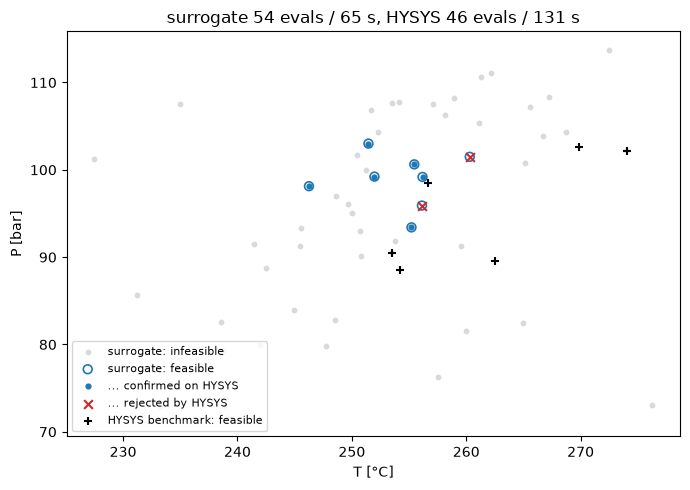

In [21]:
# Surrogate feasibility against the independent HYSYS benchmark
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sur_df.temperature_C[~sur_df.feasible], sur_df.pressure_bar[~sur_df.feasible],
           s=10, color="0.85", label="surrogate: infeasible")
ax.scatter(cand.temperature_C, cand.pressure_bar, s=40, facecolors="none", edgecolors="C0", lw=1.2,
           label="surrogate: feasible")
ax.scatter(cand.temperature_C[cand.verified], cand.pressure_bar[cand.verified], s=12, color="C0",
           label="... confirmed on HYSYS")
ax.scatter(cand.temperature_C[~cand.verified], cand.pressure_bar[~cand.verified], s=40, marker="x", color="C3",
           label="... rejected by HYSYS")
ax.scatter(hys_df.temperature_C[hys_df.feasible], hys_df.pressure_bar[hys_df.feasible], s=40, marker="+", color="k",
           label="HYSYS benchmark: feasible")
ax.set(xlabel="T [°C]", ylabel="P [bar]",
       title=f"surrogate {len(sur_df)} evals / {runs['surrogate']['wall_s']:.0f} s, "
             f"HYSYS {len(hys_df)} evals / {runs['hysys']['wall_s']:.0f} s")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()